In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

# Download the VADER lexicon for sentiment analysis
nltk.download('vader_lexicon')



[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [ ]:
import spacy
from nltk.sentiment import SentimentIntensityAnalyzer

In [ ]:
# Function to read text from a file
def read_text_file(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        return file.read()

# Load a spacy model for aspect extraction
nlp = spacy.load('en_core_web_sm')



# Function to perform ABSA on text
def aspect_based_sentiment_analysis(text):
    # Process the text with spacy to extract aspects
    doc = nlp(text)
    sia = SentimentIntensityAnalyzer()

    aspects = {}
    for chunk in doc.noun_chunks:
        aspect = chunk.root.text
        if aspect not in aspects:
            aspects[aspect] = {'text': '', 'score': 0}
        for token in chunk:
            if token.pos_ in ['ADJ']:  # Use adjectives and verbs for sentiment
                aspects[aspect]['text'] += ' ' + token.text

    # Perform sentiment analysis on the extracted aspects
    for aspect, info in aspects.items():
        sentiment = sia.polarity_scores(info['text'])
        aspects[aspect]['score'] = sentiment['compound']

    return aspects

# Main execution
file_path = '/content/drive/MyDrive/competition_dataset_text.txt'
text = read_text_file(file_path)
absa_results = aspect_based_sentiment_analysis(text)

# Display the ABSA results
for aspect, info in absa_results.items():
    print(f"Aspect: {aspect}, Sentiment score: {info['score']}, Text: {info['text']}")


Aspect: appointment, Sentiment score: 0.0, Text:  specialist eyesight actual eyesight eyesight eyesight entire whole latest medical timely eyesight migraine migraine whole eyesight eyesight migraine migraine eyesight
Aspect: breathing, Sentiment score: 0.0, Text: 
Aspect: it, Sentiment score: 0.0, Text: 
Aspect: December, Sentiment score: 0.0, Text: 
Aspect: Valentina, Sentiment score: 0.0, Text: 
Aspect: She, Sentiment score: 0.0, Text: 
Aspect: communication, Sentiment score: 0.9992, Text:  effective poor effective better positive better positive negative poor clear great excellent poor positive effective negative better clear positive clear negative excellent poor positive effective clear effective effective negative effective positive effective positive excellent poor positive positive effective excellent poor effective excellent positive effective clear negative positive poor excellent excellent positive clear negative clear effective negative effective effective Negative excellen

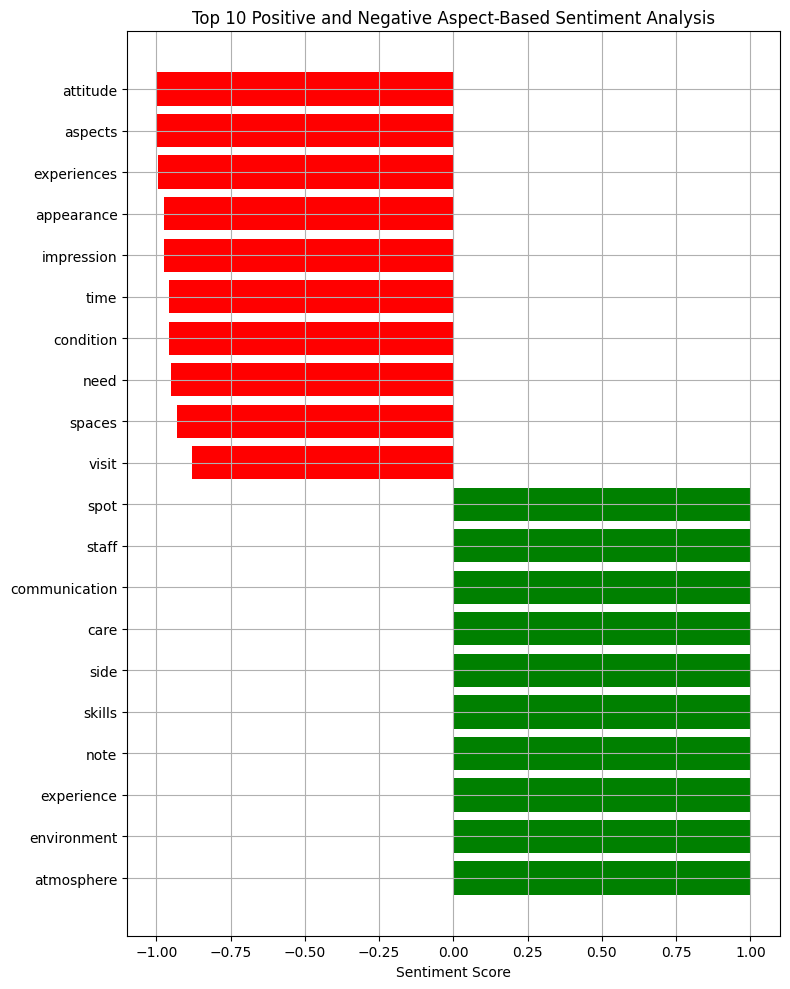

In [ ]:
import matplotlib.pyplot as plt

# Assuming `absa_results` is already defined as before

# Filter out aspects with neutral sentiment scores (e.g., scores close to 0)
filtered_aspects = {aspect: info for aspect, info in absa_results.items() if abs(info['score']) > 0.1}  # Adjust the threshold as needed

# Sort filtered aspects by their sentiment score for better readability
sorted_aspects = sorted(filtered_aspects.items(), key=lambda item: item[1]['score'], reverse=True)

# Separate the aspects and their scores, considering top 10 positive and negative values
top_aspects = sorted_aspects[:10] + sorted_aspects[-10:]  # Top 10 positive and top 10 negative
aspects = [item[0] for item in top_aspects]
scores = [item[1]['score'] for item in top_aspects]

# Create the horizontal bar chart for top positive and negative aspects
plt.figure(figsize=(8, 10))  # Adjust figure size as needed
plt.barh(aspects, scores, color=['green' if score > 0 else 'red' for score in scores])
plt.xlabel('Sentiment Score')
plt.title('Top 10 Positive and Negative Aspect-Based Sentiment Analysis')
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Example ground truth and predicted sentiments
# These should be lists of sentiment labels like 'positive', 'negative', 'neutral'
actual_sentiments = ['positive', 'helpful', 'friendly', 'pleasant', 'clean', 'welcoming', 'attentive', 'excellent', 'fantastic', 'good', 'great', 'well-equipped', 'knowledgeable', 'negative', 'disappointing', 'unhelpful', 'unfriendly', 'dirty', 'dated', 'disorganized', 'disinterested', 'difficult', 'frustrating', 'poor','lack', 'unheard', 'chaotic', 'inconvinience', 'upgrade', 'hassle', 'struggle', 'outdated', 'dissatisfied', 'unfortunate', 'not good', 'not great', 'not helpful', 'not comfortable']  # Example ground truth
predicted_sentiments = ['positive', 'positive', 'positive','positive', 'positive','positive','positive','positive','positive','positive','positive','positive','positive','negative','negative','negative','negative','negative','negative','negative','negative','negative','negative','negative','negative','negative','negative','negative','negative','negative','negative','negative','negative','negative', 'negative', 'negative', 'negative', 'negative' ]  # Example predictions

# Calculate metrics
precision = precision_score(actual_sentiments, predicted_sentiments, average='weighted', labels=np.unique(predicted_sentiments))
recall = recall_score(actual_sentiments, predicted_sentiments, average='weighted', labels=np.unique(predicted_sentiments))
f1 = f1_score(actual_sentiments, predicted_sentiments, average='weighted', labels=np.unique(predicted_sentiments))
accuracy = accuracy_score(actual_sentiments, predicted_sentiments)

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"Accuracy: {accuracy}")


Precision: 0.05846153846153847
Recall: 1.0
F1 Score: 0.1098901098901099
Accuracy: 0.05263157894736842


In [ ]:
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
import re

# Load the dataset
file_path = '/content/drive/MyDrive/competition_dataset_3_13.csv'
data = pd.read_csv(file_path, header=None, names=['Text'])

# Initialize SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

# Function to calculate sentiment scores for text containing 'doctor'
def calculate_sentiment(row):
    # Check if 'doctor' is in the text
    if re.search(r'\bdoctor\b', row['Text'], re.IGNORECASE):
        sentiment_score = sia.polarity_scores(row['Text'])
        return sentiment_score['compound']
    return None

# Apply the function to each row and create a new column for sentiment scores
data['Sentiment Score'] = data.apply(calculate_sentiment, axis=1)

# Filter out rows where 'doctor' was not mentioned
doctor_data = data.dropna(subset=['Sentiment Score'])

# Display the first few rows of the dataframe to verify
print(doctor_data.head)


<bound method NDFrame.head of                                                   Text  Sentiment Score
1    The appointment was for trouble breathing and ...           0.8715
2    In my previous experiences at this doctor's of...           0.9844
4    I was quite apprehensive when I arrived at the...          -0.9463
5    The waiting room of the office was modern and ...           0.8862
6    The appointment was for an eyesight checkup. I...          -0.9219
..                                                 ...              ...
979  I had an appointment at the doctors office wit...           0.9902
980  Parking was easy to find. The lobby and waitin...          -0.2023
982  The style of the lobby and waiting rooms was d...           0.9796
983  The ambiance of the clinic was pleasant and ca...           0.9269
984  The doctors office is conveniently located wit...           0.9201

[653 rows x 2 columns]>


In [ ]:
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
import re

# Load the dataset
file_path = '/content/drive/MyDrive/competition_dataset_3_13.csv'
data = pd.read_csv(file_path, header=None)  # Assuming the file has no header

# Initialize SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

# List of doctors to search for in the text
doctors = ['Smith', 'Valentina','Valerez', 'Danny', 'Jose', 'Tim']

# Function to calculate sentiment scores for text associated with each doctor
def calculate_doctor_sentiment(text, doctor_names):
    sentiment_scores = {}
    for doctor in doctor_names:
        # Regular expression to find sentences containing the doctor's name
        # This regex assumes that sentences end with a period followed by a space or the end of the text
        sentences = re.findall(rf'[^.]*{re.escape(doctor)}[^.]*\.', text)
        combined_text = ' '.join(sentences)
        if combined_text:
            sentiment_score = sia.polarity_scores(combined_text)['compound']
            sentiment_scores[doctor] = sentiment_score
        else:
            sentiment_scores[doctor] = None  # No text found for this doctor
    return sentiment_scores

# Assuming the text data is in the first column of the CSV
sentiment_scores = calculate_doctor_sentiment(' '.join(data[0]), doctors)

sentiment_scores


{'Smith': -1.0,
 'Valentina': 1.0,
 'Valerez': 1.0,
 'Danny': 1.0,
 'Jose': 1.0,
 'Tim': 1.0}

In [ ]:
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
import re

# Load the dataset
file_path = '/content/drive/MyDrive/competition_dataset_3_13.csv'
data = pd.read_csv(file_path, header=None)  # Assuming the file has no header

# Initialize SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

# List of Areas to search for in the text
area = ['waiting room', 'parking','reception', 'lobby', 'examination room', 'facility']

# Function to calculate sentiment scores for text associated with each doctor
def calculate_area_sentiment(text, area_names):
    sentiment_scores = {}
    for area in area_names:
        # Regular expression to find sentences containing the doctor's name
        # This regex assumes that sentences end with a period followed by a space or the end of the text
        sentences = re.findall(rf'[^.]*{re.escape(area)}[^.]*\.', text)
        combined_text = ' '.join(sentences)
        if combined_text:
            sentiment_score = sia.polarity_scores(combined_text)['compound']
            sentiment_scores[area] = sentiment_score
        else:
            sentiment_scores[area] = None  # No text found for this doctor
    return sentiment_scores

# Assuming the text data is in the first column of the CSV
sentiment_scores = calculate_doctor_sentiment(' '.join(data[0]), area)

sentiment_scores

{'waiting room': -0.9999,
 'parking': 0.9999,
 'reception': 1.0,
 'lobby': -1.0,
 'examination room': 0.9909,
 'facility': 0.9928}

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# Example sentiment scores from previous analysis
sentiment_scores_doctors = {'Smith': -1.0, 'Valentina': 1.0, 'Valerez': 1.0, 'Danny': 1.0, 'Jose': 1.0, 'Tim': 1.0}
sentiment_scores_areas = {'waiting room': -0.9999, 'parking': 0.9999, 'reception': 1.0, 'lobby': -1.0, 'examination room': 0.9909, 'facility': 0.9928}

# Create a DataFrame from the sentiment scores
data_doctors = pd.DataFrame(list(sentiment_scores_doctors.items()), columns=['Entity', 'Sentiment'])
data_areas = pd.DataFrame(list(sentiment_scores_areas.items()), columns=['Entity', 'Sentiment'])

# Add a column to distinguish between doctors and areas
data_doctors['Type'] = 'Doctor'
data_areas['Type'] = 'Area'

# Combine the data into a single DataFrame
data_combined = pd.concat([data_doctors, data_areas])

# For linear regression, we need a numerical feature. We can convert the 'Type' column into a binary feature
data_combined['IsDoctor'] = (data_combined['Type'] == 'Doctor').astype(int)

# Now we can fit a linear regression model
X = data_combined[['IsDoctor']]  # Feature matrix
y = data_combined['Sentiment']  # Target variable

model = LinearRegression()
model.fit(X, y)

# Display the coefficients of the model
print("Intercept:", model.intercept_)
print("Coefficient for IsDoctor:", model.coef_[0])


Intercept: 0.33061666666666667
Coefficient for IsDoctor: 0.33604999999999996


In [ ]:
from sklearn.linear_model import LinearRegression
import pandas as pd

# Define the data
data = {
    'waiting_room': [-0.9999, 0.9999, 1.0, -1.0, 0.9909, 0.9928],
    'parking': [0.9999, -1.0, 1.0, 1.0, 1.0, 1.0],
    'reception': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
    'lobby': [-1.0, 1.0, 1.0, -1.0, 1.0, 1.0],
    'examination_room': [0.9909, 1.0, 1.0, -1.0, 1.0, 1.0],
    'facility': [0.9928, 1.0, 1.0, -1.0, 1.0, 1.0],
    'sentiment': [0.8, 0.9, 0.95, 0.7, 0.92, 0.88]  # Example sentiment scores
}

df = pd.DataFrame(data)

# Separate features and target variable
X = df.drop('sentiment', axis=1)  # Features
y = df['sentiment']  # Target variable

# Initialize and fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Print the coefficients and intercept
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)


Coefficients: [ 5.07015767e+00  2.18537538e-02  1.66533454e-13 -4.99799926e+00
  2.25787504e-02  2.73701001e-02]
Intercept: 0.8002535078835318


In [ ]:
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
import re

# Load the dataset
file_path = '/content/drive/MyDrive/competition_dataset_3_13.csv'
data = pd.read_csv(file_path, header=None)  # Assuming the file has no header

# Initialize SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

# List of doctors and areas to search for in the text
doctors = ['Smith', 'Valentina', 'Valerez', 'Danny', 'Jose', 'Tim']
areas = ['waiting room', 'parking', 'reception', 'lobby', 'examination room', 'facility']

# Function to calculate sentiment scores for text associated with each doctor and area
def calculate_sentiment(row_text, doctor_names, area_names):
    doctor_sentiment_scores = {}
    area_sentiment_scores = {}

    for doctor in doctor_names:
        # Regular expression to find sentences containing the doctor's name
        sentences = re.findall(rf'[^.]*{re.escape(doctor)}[^.]*\.', row_text)
        combined_text = ' '.join(sentences)
        if combined_text:
            sentiment_score = sia.polarity_scores(combined_text)['compound']
            doctor_sentiment_scores[doctor] = sentiment_score
        else:
            doctor_sentiment_scores[doctor] = None  # No text found for this doctor

    for area in area_names:
        # Regular expression to find sentences containing the area name
        sentences = re.findall(rf'[^.]*{re.escape(area)}[^.]*\.', row_text)
        combined_text = ' '.join(sentences)
        if combined_text:
            sentiment_score = sia.polarity_scores(combined_text)['compound']
            area_sentiment_scores[area] = sentiment_score
        else:
            area_sentiment_scores[area] = None  # No text found for this area

    return doctor_sentiment_scores, area_sentiment_scores

# Apply the function row-wise to calculate sentiment scores for each doctor and area
data[['doctor_sentiment_scores', 'area_sentiment_scores']] = data[0].apply(lambda x: pd.Series(calculate_sentiment(x, doctors, areas)))

# Display the output DataFrame with sentiment scores for doctors and areas
print(data[['doctor_sentiment_scores', 'area_sentiment_scores']])


                               doctor_sentiment_scores  \
0    {'Smith': None, 'Valentina': None, 'Valerez': ...   
1    {'Smith': None, 'Valentina': 0.5574, 'Valerez'...   
2    {'Smith': None, 'Valentina': None, 'Valerez': ...   
3    {'Smith': None, 'Valentina': -0.5719, 'Valerez...   
4    {'Smith': None, 'Valentina': None, 'Valerez': ...   
..                                                 ...   
980  {'Smith': -0.5719, 'Valentina': None, 'Valerez...   
981  {'Smith': None, 'Valentina': -0.5719, 'Valerez...   
982  {'Smith': None, 'Valentina': 0.5574, 'Valerez'...   
983  {'Smith': None, 'Valentina': 0.6808, 'Valerez'...   
984  {'Smith': None, 'Valentina': None, 'Valerez': ...   

                                 area_sentiment_scores  
0    {'waiting room': None, 'parking': None, 'recep...  
1    {'waiting room': -0.4215, 'parking': -0.3612, ...  
2    {'waiting room': 0.7964, 'parking': 0.1531, 'r...  
3    {'waiting room': -0.3612, 'parking': 0.0772, '...  
4    {'waiting roo

In [ ]:
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
import re
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load the dataset
file_path = '/content/drive/MyDrive/competition_dataset_3_13.csv'
data = pd.read_csv(file_path, header=None)  # Assuming the file has no header

# Initialize SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

# List of doctors and areas to search for in the text
doctors = ['Smith', 'Valentina', 'Valerez', 'Danny', 'Jose', 'Tim']
areas = ['waiting room', 'parking', 'reception', 'lobby', 'examination room', 'facility']

# Function to calculate sentiment scores for text associated with each doctor and area
def calculate_sentiment(row_text, doctor_names, area_names):
    doctor_sentiment_scores = {}
    area_sentiment_scores = {}

    for doctor in doctor_names:
        # Regular expression to find sentences containing the doctor's name
        sentences = re.findall(rf'[^.]*{re.escape(doctor)}[^.]*\.', row_text)
        combined_text = ' '.join(sentences)
        if combined_text:
            sentiment_score = sia.polarity_scores(combined_text)['compound']
            doctor_sentiment_scores[doctor] = sentiment_score
        else:
            doctor_sentiment_scores[doctor] = None  # No text found for this doctor

    for area in area_names:
        # Regular expression to find sentences containing the area name
        sentences = re.findall(rf'[^.]*{re.escape(area)}[^.]*\.', row_text)
        combined_text = ' '.join(sentences)
        if combined_text:
            sentiment_score = sia.polarity_scores(combined_text)['compound']
            area_sentiment_scores[area] = sentiment_score
        else:
            area_sentiment_scores[area] = None  # No text found for this area

    return doctor_sentiment_scores, area_sentiment_scores

# Apply the function row-wise to calculate sentiment scores for each doctor and area
data[['doctor_sentiment_scores', 'area_sentiment_scores']] = data[0].apply(lambda x: pd.Series(calculate_sentiment(x, doctors, areas)))

# Define a threshold for poor reviews
poor_reviews_threshold = -0.5
# Handle None values by replacing them with -1.0 (or any other default value)
data['doctor_sentiment_scores'] = data['doctor_sentiment_scores'].apply(lambda x: {k: v if v is not None else -1.0 for k, v in x.items()})
data['poor_review'] = data['doctor_sentiment_scores'].apply(lambda x: any(score < poor_reviews_threshold for score in x.values()))

# Flatten the dictionaries into separate columns
doctor_sentiment_df = data['doctor_sentiment_scores'].apply(pd.Series)
area_sentiment_df = data['area_sentiment_scores'].apply(pd.Series)

# Combine sentiment scores with other features
X = pd.concat([doctor_sentiment_df, area_sentiment_df], axis=1)  # Features are sentiment scores
y = data['poor_review'].astype(int)  # Convert boolean to integer (0 and 1)

# Handle NA values (if any) by replacing them with -1.0 (default value)
imputer = SimpleImputer(missing_values=pd.NA, strategy='constant', fill_value=-1.0)
X_imputed = imputer.fit_transform(X)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42)


# Build an XGBoost classifier
model = XGBClassifier()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Generate a classification report
print(classification_report(y_test, y_pred))

# You can further analyze the feature importance provided by XGBoost
feature_importance = model.feature_importances_
print('Feature Importance:', feature_importance)


ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0], got [1]

In [ ]:
# Assuming y_train contains non-binary classes such as 'negative' and 'positive'
# You can map 'negative' to 0 and 'positive' to 1
y_train = y_train.map({'negative': 0, 'positive': 1})

# Now check the unique values in y_train after mapping
unique_classes = y_train.unique()
print(unique_classes)  # Print unique classes to inspect



[nan]


In [ ]:
# Assuming y_train contains non-binary classes such as 'negative' and 'positive'
# You can map 'negative' to 0 and 'positive' to 1
y_train = y_train.map({'negative': 0, 'positive': 1})

# Handle missing values by filling them with a default value (e.g., -1)
y_train.fillna(-1, inplace=True)

# Now check the unique values in y_train after mapping and handling missing values
unique_classes = y_train.unique()
print(unique_classes)  # Print unique classes to inspect




[-1.]


In [ ]:
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
import re
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load the dataset
file_path = '/content/drive/MyDrive/competition_dataset_3_13.csv'
data = pd.read_csv(file_path, header=None)  # Assuming the file has no header

# Initialize SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

# List of doctors and areas to search for in the text
doctors = ['Smith', 'Valentina', 'Valerez', 'Danny', 'Jose', 'Tim']
areas = ['waiting room', 'parking', 'reception', 'lobby', 'examination room', 'facility']

# Function to calculate sentiment scores for text associated with each doctor and area
def calculate_sentiment(row_text, doctor_names, area_names):
    doctor_sentiment_scores = {}
    area_sentiment_scores = {}

    for doctor in doctor_names:
        # Regular expression to find sentences containing the doctor's name
        sentences = re.findall(rf'[^.]*{re.escape(doctor)}[^.]*\.', row_text)
        combined_text = ' '.join(sentences)
        if combined_text:
            sentiment_score = sia.polarity_scores(combined_text)['compound']
            doctor_sentiment_scores[doctor] = sentiment_score
        else:
            doctor_sentiment_scores[doctor] = None  # No text found for this doctor

    for area in area_names:
        # Regular expression to find sentences containing the area name
        sentences = re.findall(rf'[^.]*{re.escape(area)}[^.]*\.', row_text)
        combined_text = ' '.join(sentences)
        if combined_text:
            sentiment_score = sia.polarity_scores(combined_text)['compound']
            area_sentiment_scores[area] = sentiment_score
        else:
            area_sentiment_scores[area] = None  # No text found for this area

    return doctor_sentiment_scores, area_sentiment_scores

# Apply the function row-wise to calculate sentiment scores for each doctor and area
data[['doctor_sentiment_scores', 'area_sentiment_scores']] = data[0].apply(lambda x: pd.Series(calculate_sentiment(x, doctors, areas)))

# Define a threshold for poor reviews
poor_reviews_threshold = -0.6
# Handle None values by replacing them with -1.0 (or any other default value)
data['doctor_sentiment_scores'] = data['doctor_sentiment_scores'].apply(lambda x: {k: v if v is not None else 0.0 for k, v in x.items()})
data['doctor_sentiment_scores'] = data['doctor_sentiment_scores'].apply(lambda x: {k: -1.0 if v < poor_reviews_threshold else 1.0 for k, v in x.items()})
data['poor_review'] = data['doctor_sentiment_scores'].apply(lambda x: any(score < poor_reviews_threshold for score in x.values()))

# Flatten the dictionaries into separate columns
doctor_sentiment_df = data['doctor_sentiment_scores'].apply(pd.Series)
area_sentiment_df = data['area_sentiment_scores'].apply(pd.Series)

# Combine sentiment scores with other features
X = pd.concat([doctor_sentiment_df, area_sentiment_df], axis=1)  # Features are sentiment scores
y = data['poor_review'].astype(int)  # Convert boolean to integer (0 and 1)

# Handle NA values (if any) by replacing them with -1.0 (default value)
imputer = SimpleImputer(missing_values=pd.NA, strategy='constant', fill_value=0.0)
X_imputed = imputer.fit_transform(X)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42)

# Check if y_train contains only binary values (0 and 1)
unique_classes = y_train.unique()
if len(unique_classes) != 2 or sorted(unique_classes) != [0, 1]:
    raise ValueError("Invalid classes in target variable. Expected binary classes (0 and 1).")

# Build an XGBoost classifier
model = XGBClassifier()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Generate a classification report
print(classification_report(y_test, y_pred))

# You can further analyze the feature importance provided by XGBoost
feature_importance = model.feature_importances_
print('Feature Importance:', feature_importance)


Accuracy: 0.99
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       152
           1       1.00      0.98      0.99        45

    accuracy                           0.99       197
   macro avg       1.00      0.99      0.99       197
weighted avg       0.99      0.99      0.99       197

Feature Importance: [2.76197702e-01 2.70217657e-01 2.28854910e-01 0.00000000e+00
 1.19284034e-01 1.04468450e-01 1.32838613e-04 1.93615153e-04
 4.35142603e-04 2.15699576e-04 0.00000000e+00 0.00000000e+00]
